In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cs-training.csv to cs-training.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'figure.dpi':200, 'figure.figsize':(10,5)})
sns.set_style('darkgrid')
pd.set_option('display.float_format','{:.4f}'.format)

df = pd.read_csv('cs-training.csv',index_col=0)
print(df.shape)
df.head()

(150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.7661,45,2,0.8030,9120.0000,13,0,6,0,2.0000
2,0,0.9572,40,0,0.1219,2600.0000,4,0,0,0,1.0000
3,0,0.6582,38,1,0.0851,3042.0000,2,1,0,0,0.0000
4,0,0.2338,30,0,0.0360,3300.0000,5,0,0,0,0.0000
5,0,0.9072,49,1,0.0249,63588.0000,7,0,1,0,0.0000


In [ ]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.0000,150000.0000,150000.0000,150000.0000,150000.0000,120269.0000,150000.0000,150000.0000,150000.0000,150000.0000,146076.0000
mean,0.0668,6.0484,52.2952,0.4210,353.0051,6670.2212,8.4528,0.2660,1.0182,0.2404,0.7572
std,0.2497,249.7554,14.7719,4.1928,2037.8185,14384.6742,5.1460,4.1693,1.1298,4.1552,1.1151
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,0.0299,41.0000,0.0000,0.1751,3400.0000,5.0000,0.0000,0.0000,0.0000,0.0000
50%,0.0000,0.1542,52.0000,0.0000,0.3665,5400.0000,8.0000,0.0000,1.0000,0.0000,0.0000
75%,0.0000,0.5590,63.0000,0.0000,0.8683,8249.0000,11.0000,0.0000,2.0000,0.0000,1.0000
max,1.0000,50708.0000,109.0000,98.0000,329664.0000,3008750.0000,58.0000,98.0000,54.0000,98.0000,20.0000


In [ ]:
print(df.isnull().sum())
print()


SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64



In [ ]:
df['NumberOfTime30-59DaysPastDueNotWorse'].value_counts().sort_index()


,count
NumberOfTime30-59DaysPastDueNotWorse,
0,126018
1,16033
2,4598
3,1754
4,747
5,342
6,140
7,54
8,25


In [ ]:
df['NumberOfTime60-89DaysPastDueNotWorse'].value_counts().sort_index()

,count
NumberOfTime60-89DaysPastDueNotWorse,
0,142396
1,5731
2,1118
3,318
4,105
5,34
6,16
7,9
8,2


In [ ]:
df['NumberOfTimes90DaysLate'].value_counts().sort_index()

,count
NumberOfTimes90DaysLate,
0,141662
1,5243
2,1555
3,667
4,291
5,131
6,80
7,38
8,21


In [ ]:
for col in ['NumberOfTime30-59DaysPastDueNotWorse','NumberOfTime60-89DaysPastDueNotWorse','NumberOfTimes90DaysLate']:
  print(f'{col}:')
  print(f'96 count: {(df[col]==96).sum()}')
  print(f'98 count: {(df[col]==98).sum()}')

NumberOfTime30-59DaysPastDueNotWorse:
96 count: 5
98 count: 264
NumberOfTime60-89DaysPastDueNotWorse:
96 count: 5
98 count: 264
NumberOfTimes90DaysLate:
96 count: 5
98 count: 264


In [ ]:
mask_96_98 = ((df['NumberOfTime30-59DaysPastDueNotWorse']<=95) & (df['NumberOfTime60-89DaysPastDueNotWorse']<=95) & (df['NumberOfTimes90DaysLate']<=95))
print(df[mask_96_98].shape)

(149731, 11)


In [ ]:
print('Default Rate in Sentinel rows: ',df[~mask_96_98]['SeriousDlqin2yrs'].mean())

Default Rate in Sentinel rows:  0.5464684014869888


In [ ]:
df = df[mask_96_98].copy()
print(df.shape)

(149731, 11)


In [ ]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,149731.0000,149731.0000,149731.0000,149731.0000,149731.0000,120121.0000,149731.0000,149731.0000,149731.0000,149731.0000,145838.0000
mean,0.0660,6.0575,52.3276,0.2458,353.6290,6675.2889,8.4679,0.0905,1.0201,0.0648,0.7579
std,0.2482,249.9795,14.7549,0.6978,2039.5947,14392.4877,5.1381,0.4855,1.1300,0.3301,1.1154
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,0.0298,41.0000,0.0000,0.1760,3400.0000,5.0000,0.0000,0.0000,0.0000,0.0000
50%,0.0000,0.1535,52.0000,0.0000,0.3671,5400.0000,8.0000,0.0000,1.0000,0.0000,0.0000
75%,0.0000,0.5556,63.0000,0.0000,0.8700,8250.0000,11.0000,0.0000,2.0000,0.0000,1.0000
max,1.0000,50708.0000,109.0000,13.0000,329664.0000,3008750.0000,58.0000,17.0000,54.0000,11.0000,20.0000


In [ ]:
print(df['age'].value_counts().sort_index())

age
0        1
21     161
22     409
23     627
24     798
      ... 
102      3
103      3
105      1
107      1
109      2
Name: count, Length: 86, dtype: int64


In [ ]:
print(df[df['age']==0])

       SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
65696                 0                                1.0000    0   

       NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
65696                                     1     0.4369      6000.0000   

       NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
65696                                6                        0   

       NumberRealEstateLoansOrLines  NumberOfTime60-89DaysPastDueNotWorse  \
65696                             2                                     0   

       NumberOfDependents  
65696              2.0000  


In [ ]:
df = df[df['age']>0].copy()

In [ ]:
df.shape

(149730, 11)

In [ ]:
print((df['DebtRatio']>1).sum())
print((df['DebtRatio']>100).sum())
print((df['DebtRatio']>1000).sum())

35109
24377
16892


In [ ]:
print(df[df['DebtRatio']>100])

        SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
7                      0                                0.3057   57   
15                     0                                0.0197   76   
17                     0                                0.0611   78   
33                     0                                0.0834   62   
45                     0                                0.3689   68   
...                  ...                                   ...  ...   
149968                 0                                0.9779   63   
149976                 0                                0.0221   58   
149978                 0                                0.2364   29   
149993                 0                                0.8720   50   
149998                 0                                0.2460   58   

        NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
7                                          0  5710.0000            NaN   

In [ ]:
df['DebtRatio'] = df['DebtRatio'].clip(upper=10)



In [ ]:
print(df['DebtRatio'].max())
print(df['DebtRatio'].describe())

10.0
count   149730.0000
mean         2.2655
std          3.8363
min          0.0000
25%          0.1760
50%          0.3671
75%          0.8700
max         10.0000
Name: DebtRatio, dtype: float64


In [ ]:
print((df['RevolvingUtilizationOfUnsecuredLines']>1).sum())

3321


In [ ]:
df['RevolvingUtilizationOfUnsecuredLines'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(upper=1)
print(df['RevolvingUtilizationOfUnsecuredLines'].max())
print(df['RevolvingUtilizationOfUnsecuredLines'].describe())

1.0
count   149730.0000
mean         0.3180
std          0.3486
min          0.0000
25%          0.0298
50%          0.1535
75%          0.5556
max          1.0000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64


In [ ]:
df['MonthlyIncome_Missing'] = df['MonthlyIncome'].isnull().astype(int)

In [ ]:
df.shape

(149730, 12)

In [ ]:
print(df['MonthlyIncome_Missing'].value_counts())
print(df['MonthlyIncome_Missing'].sum())


MonthlyIncome_Missing
0    120120
1     29610
Name: count, dtype: int64
29610


In [ ]:
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].median())

In [ ]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_Missing
1,1,0.7661,45,2,0.8030,9120.0000,13,0,6,0,2.0000,0
2,0,0.9572,40,0,0.1219,2600.0000,4,0,0,0,1.0000,0
3,0,0.6582,38,1,0.0851,3042.0000,2,1,0,0,0.0000,0
4,0,0.2338,30,0,0.0360,3300.0000,5,0,0,0,0.0000,0
5,0,0.9072,49,1,0.0249,63588.0000,7,0,1,0,0.0000,0


In [ ]:
print(df.isnull().sum())

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
MonthlyIncome_Missing                   0
dtype: int64


In [ ]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_Missing
count,149730.0000,149730.0000,149730.0000,149730.0000,149730.0000,149730.0000,149730.0000,149730.0000,149730.0000,149730.0000,149730.0000,149730.0000
mean,0.0660,0.3180,52.3280,0.2458,2.2655,6423.0975,8.4679,0.0905,1.0201,0.0648,0.7381,0.1978
std,0.2482,0.3486,14.7544,0.6978,3.8363,12901.1213,5.1381,0.4855,1.1300,0.3301,1.1074,0.3983
min,0.0000,0.0000,21.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,0.0298,41.0000,0.0000,0.1760,3915.0000,5.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,0.0000,0.1535,52.0000,0.0000,0.3671,5400.0000,8.0000,0.0000,1.0000,0.0000,0.0000,0.0000
75%,0.0000,0.5556,63.0000,0.0000,0.8700,7400.0000,11.0000,0.0000,2.0000,0.0000,1.0000,0.0000
max,1.0000,1.0000,109.0000,13.0000,10.0000,3008750.0000,58.0000,17.0000,54.0000,11.0000,20.0000,1.0000


In [ ]:
print(df['NumberOfDependents'].value_counts().sort_index())
print(df['NumberOfOpenCreditLinesAndLoans'].value_counts().sort_index())
print(df['NumberRealEstateLoansOrLines'].value_counts().sort_index())

NumberOfDependents
0.0000     90607
1.0000     26293
2.0000     19501
3.0000      9479
4.0000      2860
5.0000       745
6.0000       158
7.0000        51
8.0000        24
9.0000         5
10.0000        5
13.0000        1
20.0000        1
Name: count, dtype: int64
NumberOfOpenCreditLinesAndLoans
0      1621
1      4436
2      6666
3      9058
4     11609
5     12931
6     13613
7     13245
8     12562
9     11355
10     9624
11     8321
12     7005
13     5667
14     4546
15     3645
16     3000
17     2370
18     1874
19     1433
20     1169
21      864
22      685
23      533
24      422
25      337
26      239
27      194
28      150
29      114
30       88
31       74
32       52
33       47
34       35
35       27
36       18
37        7
38       13
39        9
40       10
41        4
42        8
43        8
44        2
45        8
46        3
47        2
48        6
49        4
50        2
51        2
52        3
53        1
54        4
56        2
57        2
58        1
Name: 

In [ ]:
df['NumberOfDependents'] = df['NumberOfDependents'].clip(upper=10)
df['NumberRealEstateLoansOrLines'] = df['NumberRealEstateLoansOrLines'].clip(upper=10)

In [ ]:
df.to_csv('cs-training-cleaned.csv')
print('Saved. Shape:', df.shape)

Saved. Shape: (149730, 12)


In [ ]:
target = 'SeriousDlqin2yrs'
counts = df[target].value_counts()
ratio = counts[0]/counts[1]
print(f'Class 0 (no default): {counts[0]:,} ({counts[0]/len(df)*100:.1f}%)')
print(f'Class 1 (default):    {counts[1]:,} ({counts[1]/len(df)*100:.1f}%)')
print(f'Imbalance ratio:      {ratio:.1f}:1')

Class 0 (no default): 139,851 (93.4%)
Class 1 (default):    9,879 (6.6%)
Imbalance ratio:      14.2:1


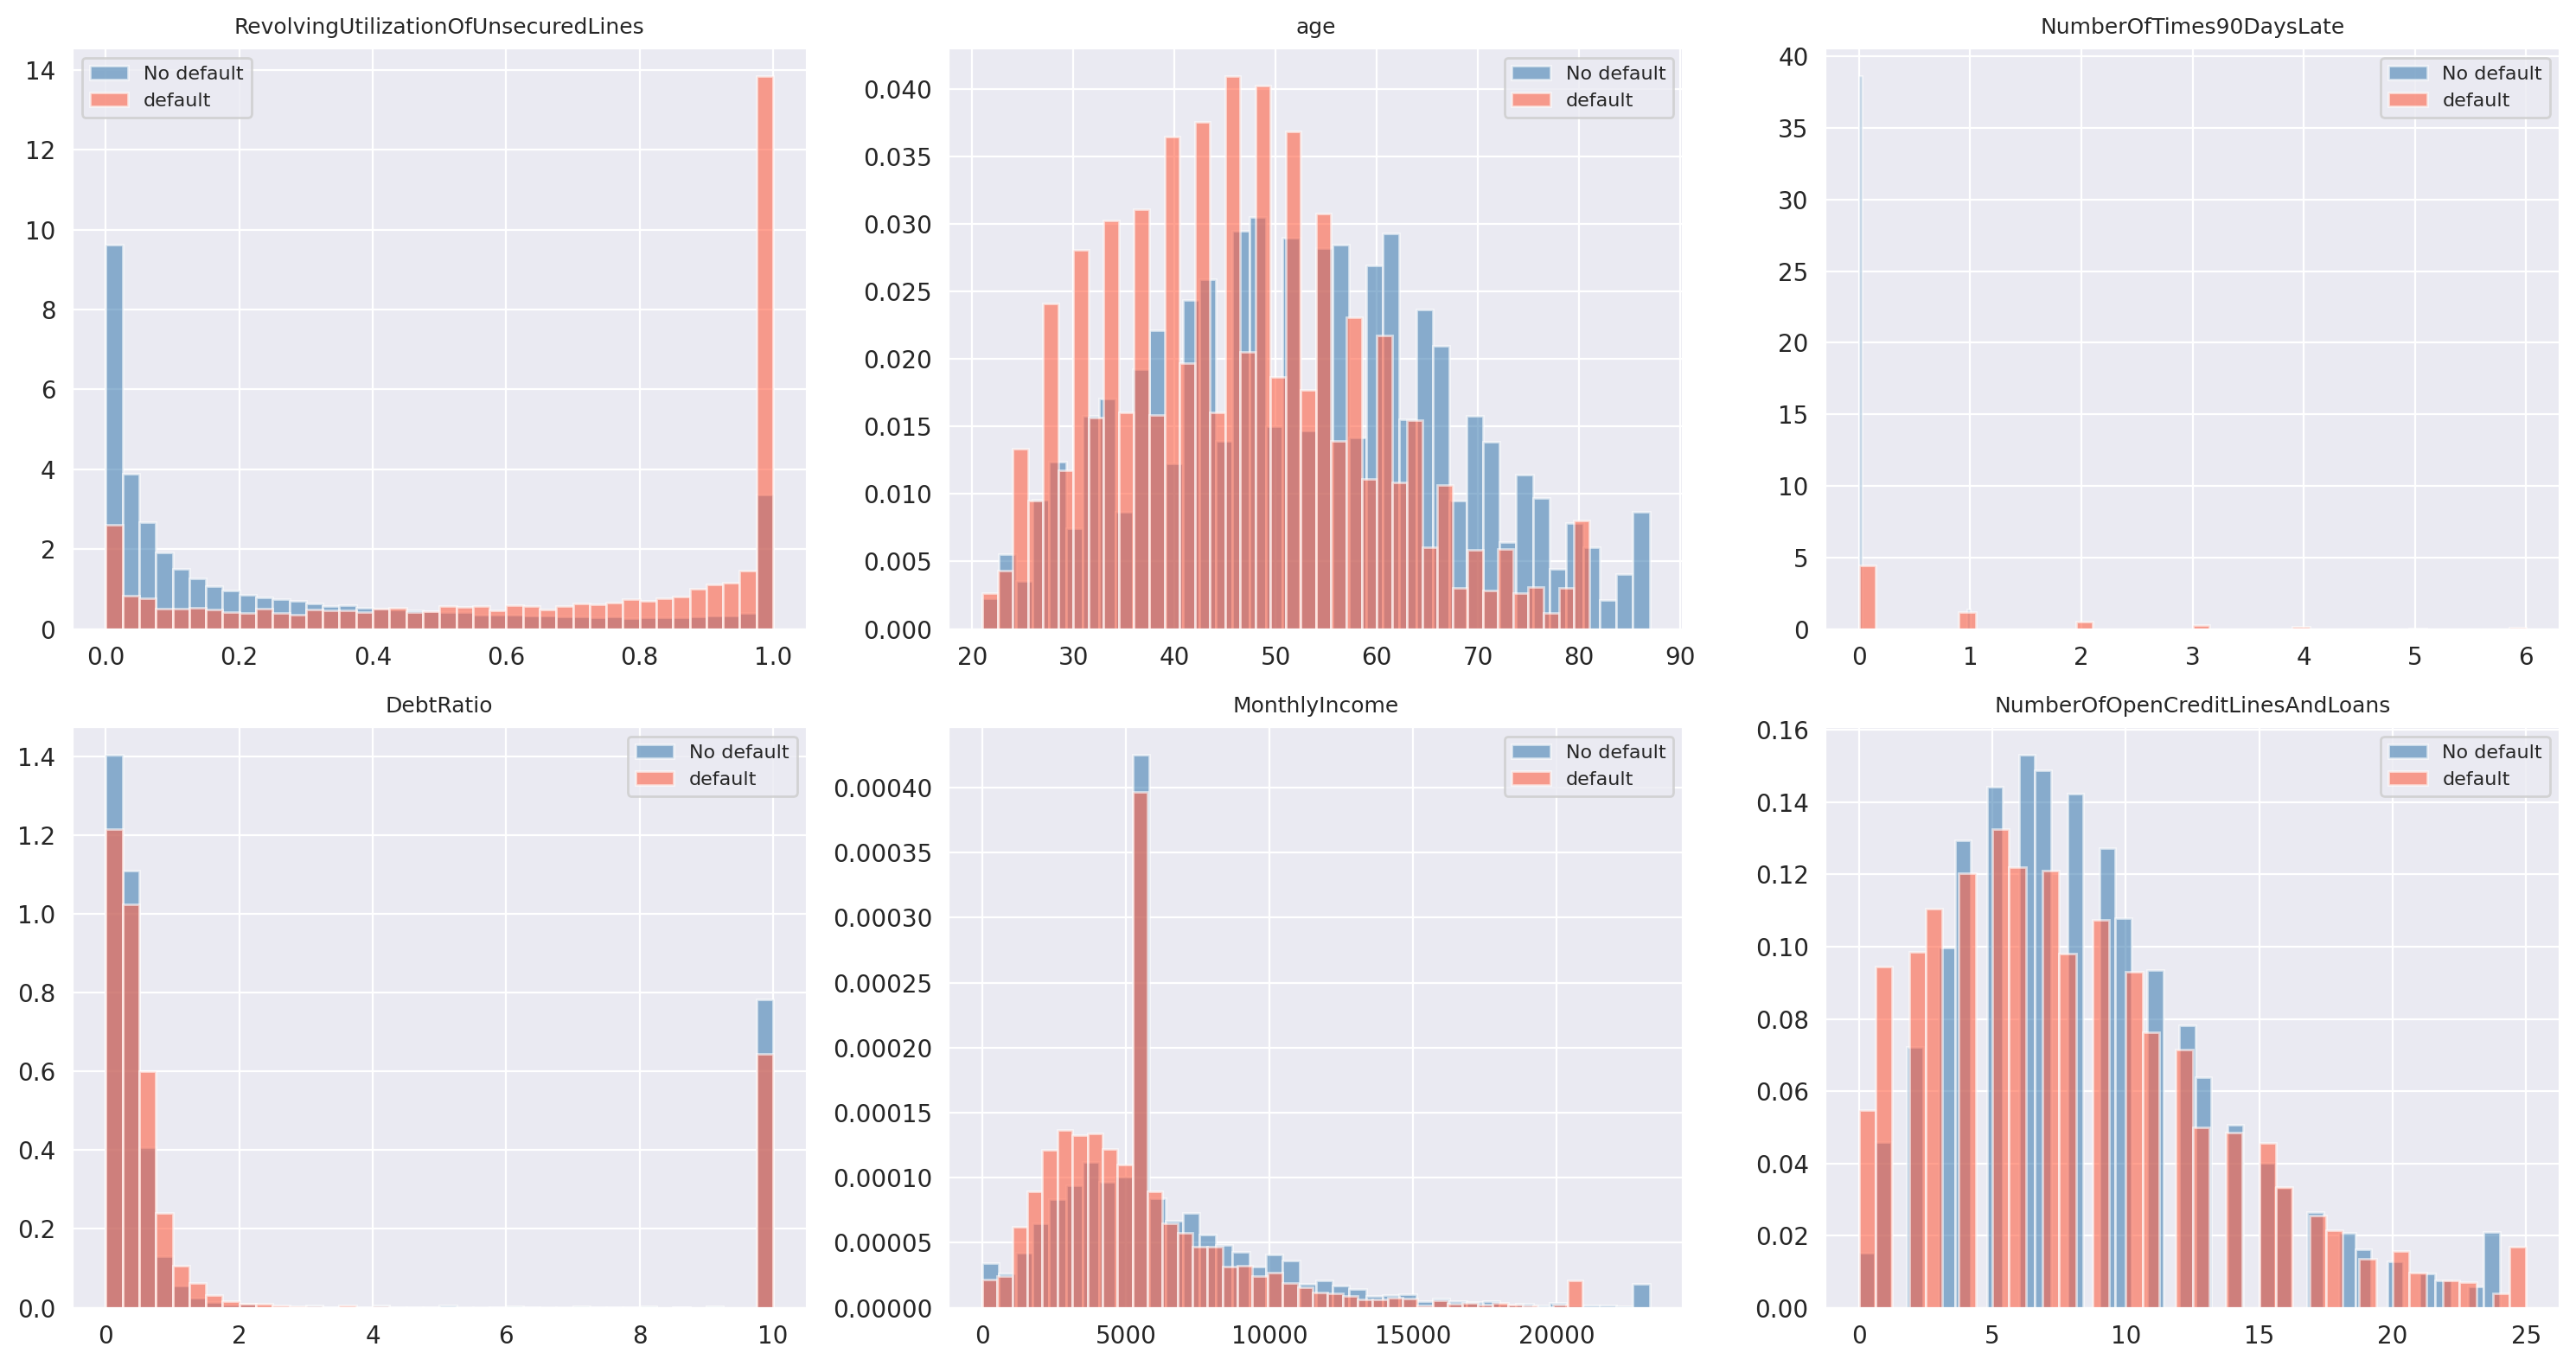

In [ ]:
features = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'NumberOfTimes90DaysLate',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans',
]

fig,axes = plt.subplots(2,3,figsize=(15,8))
for ax, feat in zip(axes.flat,features):
  for cls, color, label in [(0,'steelblue','No default'),(1,'tomato','default')]:
    data = df[df[target]==cls][feat]
    cap = data.quantile(0.99)
    data.clip(upper=cap).hist(bins=40, ax=ax, alpha=0.6, color=color, label=label, density=True)
    ax.set_title(feat, fontsize=9)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
late_default = df.groupby('NumberOfTimes90DaysLate')[target].agg(['mean', 'count'])
print(late_default.head(10))

                          mean   count
NumberOfTimes90DaysLate               
0                       0.0463  141661
1                       0.3366    5243
2                       0.4990    1555
3                       0.5772     667
4                       0.6701     291
5                       0.6336     131
6                       0.6000      80
7                       0.8158      38
8                       0.7143      21
9                       0.7368      19


In [ ]:
for col in ['NumberOfTime30-59DaysPastDueNotWorse',
            'NumberOfTime60-89DaysPastDueNotWorse']:
    print(f'\n{col}')
    print(df.groupby(col)[target].agg(['mean', 'count']).head(8))


NumberOfTime30-59DaysPastDueNotWorse
                                       mean   count
NumberOfTime30-59DaysPastDueNotWorse               
0                                    0.0400  126018
1                                    0.1503   16032
2                                    0.2651    4598
3                                    0.3523    1754
4                                    0.4257     747
5                                    0.4503     342
6                                    0.5286     140
7                                    0.5185      54

NumberOfTime60-89DaysPastDueNotWorse
                                       mean   count
NumberOfTime60-89DaysPastDueNotWorse               
0                                    0.0510  142395
1                                    0.3101    5731
2                                    0.5018    1118
3                                    0.5660     318
4                                    0.6190     105
5                                    0.6

In [ ]:
print((df['MonthlyIncome']).value_counts())

MonthlyIncome
5400.0000     29941
5000.0000      2757
4000.0000      2105
6000.0000      1932
3000.0000      1752
              ...  
18001.0000        1
7919.0000         1
10374.0000        1
17163.0000        1
11455.0000        1
Name: count, Length: 13591, dtype: int64


In [ ]:
print(df.groupby('MonthlyIncome_Missing')[target].agg(['mean', 'count']))

                        mean   count
MonthlyIncome_Missing               
0                     0.0689  120120
1                     0.0542   29610


In [ ]:
print(df['MonthlyIncome_Missing'].value_counts())
print(df['MonthlyIncome_Missing'].sum())

MonthlyIncome_Missing
0    120120
1     29610
Name: count, dtype: int64
29610


In [ ]:
df['DebtRatio'].describe()

,DebtRatio
count,149730.0000
mean,2.2655
std,3.8363
min,0.0000
25%,0.1760
50%,0.3671
75%,0.8700
max,10.0000


In [ ]:
df['DebtRatio_Bin'] = pd.cut(df['DebtRatio'],bins=[0,1,2,3,5,10],include_lowest=True)
print(df.groupby('DebtRatio_Bin',observed=True)[target].agg(['mean','count']))

                mean   count
DebtRatio_Bin               
(-0.001, 1.0] 0.0664  114621
(1.0, 2.0]    0.1317    4092
(2.0, 3.0]    0.0932     762
(3.0, 5.0]    0.0612     637
(5.0, 10.0]   0.0547   29618


In [ ]:
print(df.groupby('NumberOfDependents')[target].agg(['mean','count']))

                     mean  count
NumberOfDependents              
0.0000             0.0569  90607
1.0000             0.0731  26293
2.0000             0.0806  19501
3.0000             0.0879   9479
4.0000             0.1035   2860
5.0000             0.0913    745
6.0000             0.1519    158
7.0000             0.0980     51
8.0000             0.0833     24
9.0000             0.0000      5
10.0000            0.0000      7


In [ ]:
print(df.groupby('NumberRealEstateLoansOrLines')[target].agg(['mean','count']))

                               mean  count
NumberRealEstateLoansOrLines              
0                            0.0809  55919
1                            0.0525  52338
2                            0.0560  31521
3                            0.0670   6300
4                            0.0894   2170
5                            0.1205    689
6                            0.1500    320
7                            0.1813    171
8                            0.2473     93
9                            0.1795     78
10                           0.1985    131


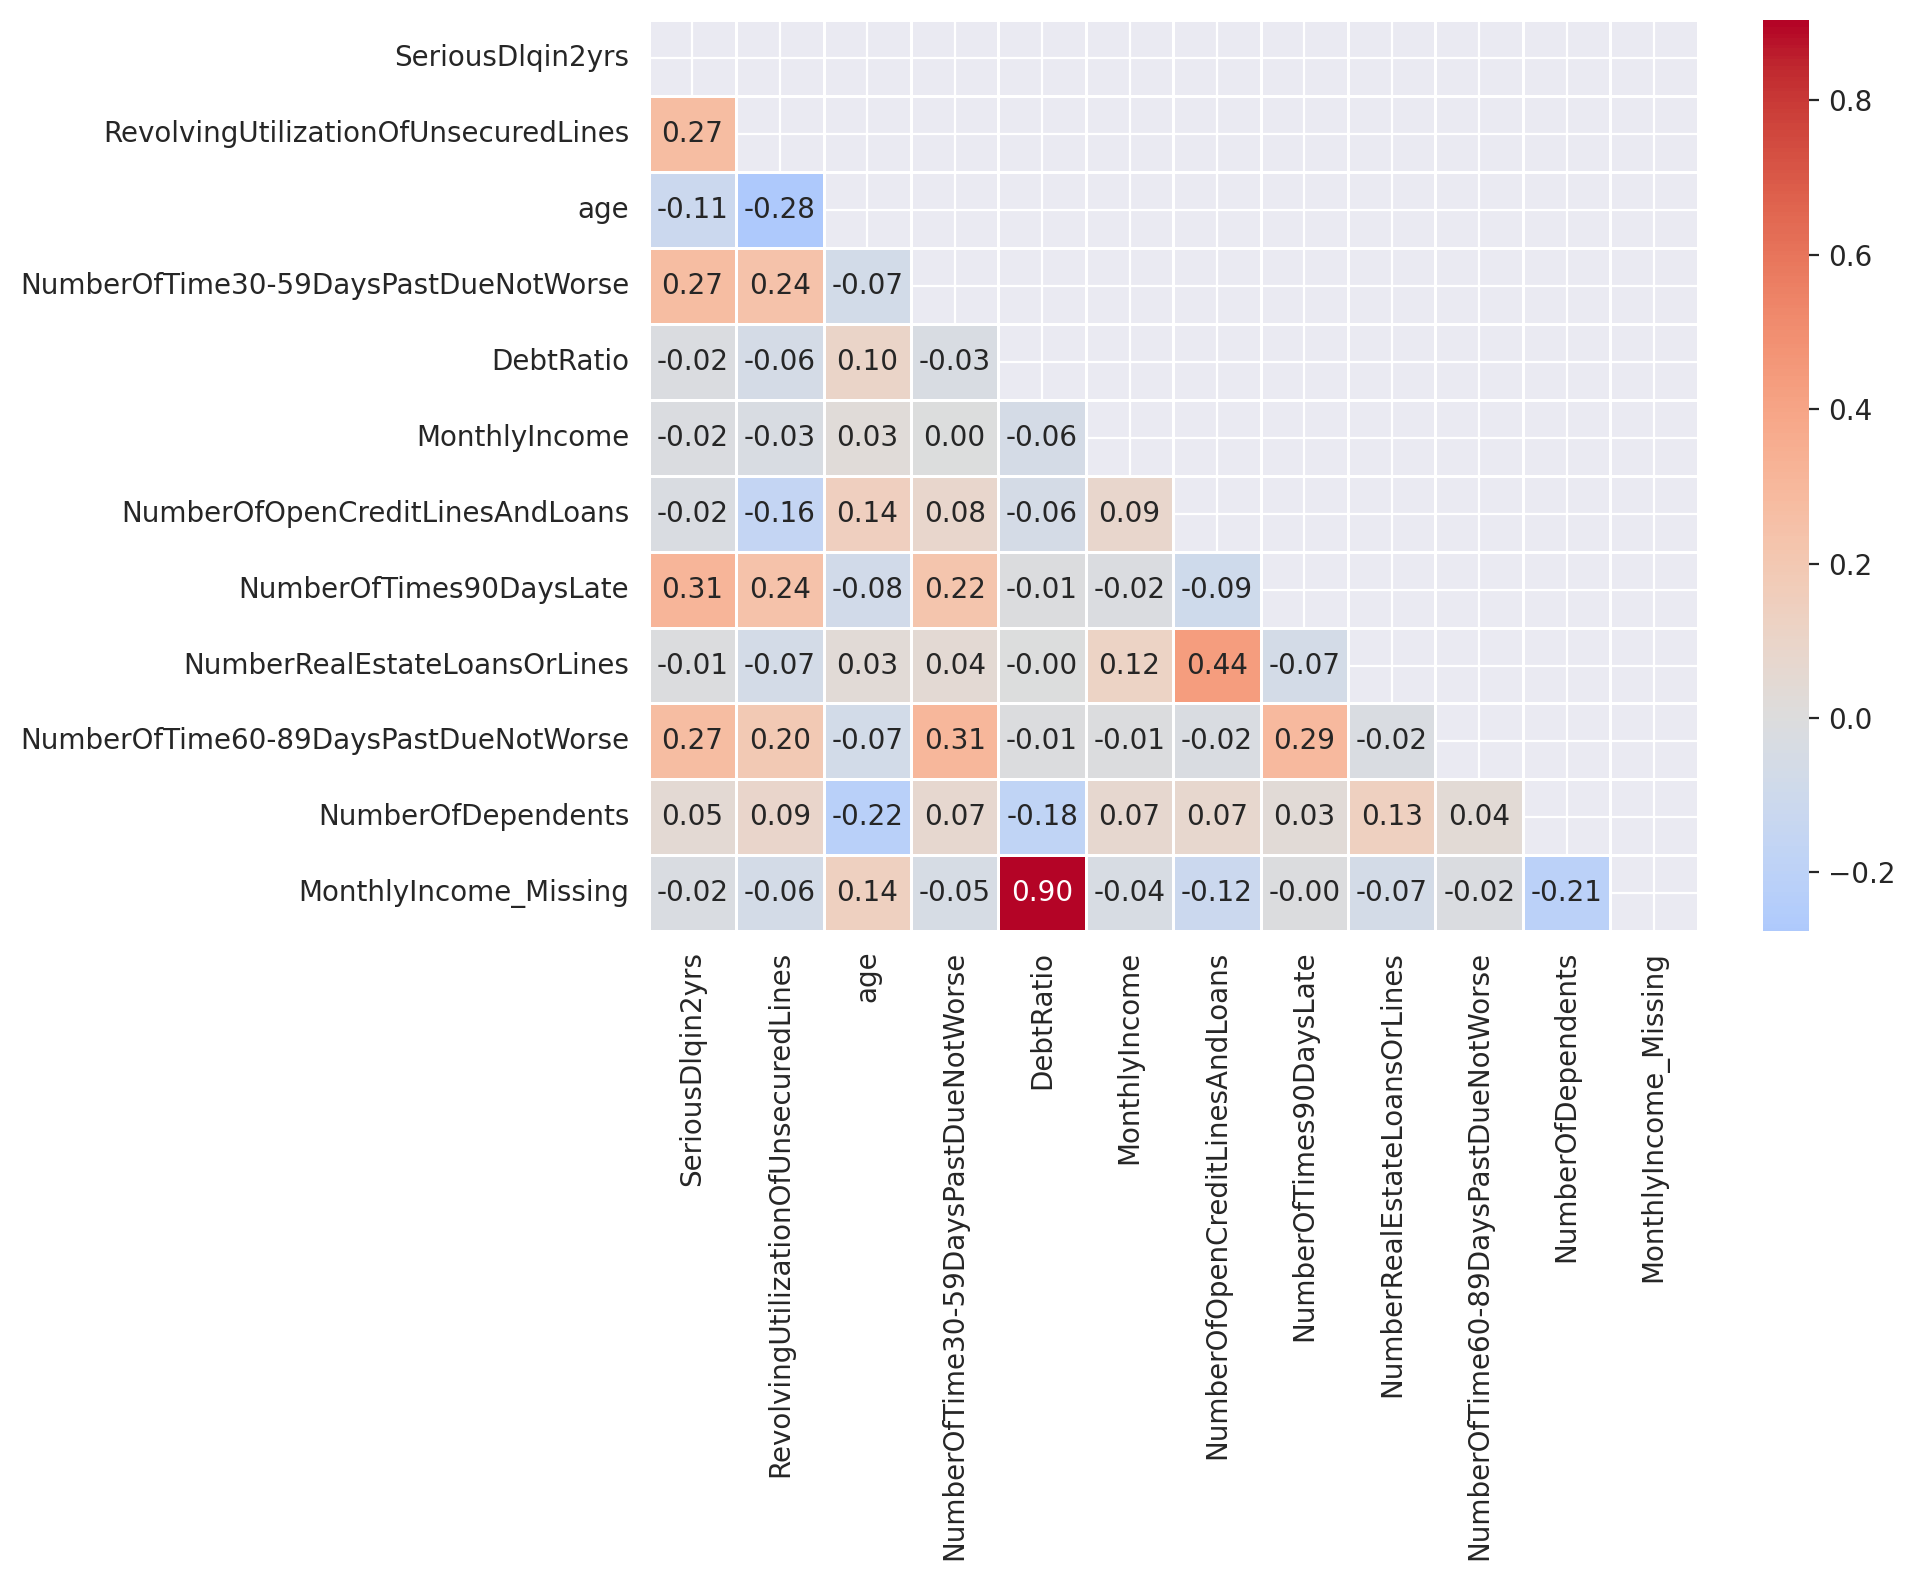

In [ ]:
corr = df.drop(columns=['DebtRatio_Bin']).corr()
fig, ax = plt.subplots(figsize=(10,8))
import numpy as np
mask = np.triu(np.ones_like(corr,dtype=bool))
sns.heatmap(corr,mask=mask,annot=True,fmt='.2f',cmap='coolwarm',center=0,linewidth=0.5,ax=ax)
plt.tight_layout()
plt.show()

# EDA Summary

## Data Quality
- Started with 150,000 rows, cleaned to 149,730
- Issues found and actions taken (sentinel values, age=0, caps applied, nulls imputed)

## Class Imbalance
- X:1 ratio, directly motivates A3

## Feature Signal Strength
###Strong:
- RevolvingUtilizationOfUnsecuredLines
- age
- NumberOfTime30-59DaysPastDueNotWorse
- NumberOfTime60-89DaysPastDueNotWorse
- NumberOfTimes90DaysLate


###Moderate:
- NumberRealEstateLoansOrLines
- NumberOfOpenCreditLinesAndLoans


### Weak/Unreliable:
- NumberOfDependents
- DebtRatio
- MonthlyIncome
- MonthlyIncome_missing

### Key Findings
- Highly imbalanced dataset. Complete focus on defaulters
- DebtRatio is a misleading feature as many rows have missing salary
- Number of 90-day late payments is the strongest individual predictor — going from 0 to 1 occurrence alone jumps default rate from 4.6% to 33.7%, and the relationship is monotonic across all three delinquency columns
- assumed missing monthly income would indicate failure but no such relation was found
----




### Feature Engineering Hypotheses for A2
- **Weighted delinquency score —** combine three delinquency columns with weights 1, 2, 3 by severity
- **Age bins** — capture the younger=riskier pattern
- **Log transform on MonthlyIncome** — handle right skew
- **HasMortgage binary flag** — capture the U-shape in RealEstateLoans
- **Interaction between age and RevolvingUtilization** — younger people with high utilization are especially risky